In [1]:
import os
import importlib
import sys
import torch

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
os.environ['AMPLFI_OUTDIR'] = '/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/sg'
os.environ['AMPLFI_DATADIR'] = '/home/aframe/dev/o4_llpic/amplfi/hl/data'
config_path ='/home/jack.redepenning/amplfi_dir/amplfi/runs/sg/sg.yaml'

In [2]:
module_path = "/home/jack.redepenning/amplfi_dir/amplfi/amplfi/__init__.py"
module_name = "amplfi"

In [3]:
spec = importlib.util.spec_from_file_location(module_name, module_path)
amplfi = importlib.util.module_from_spec(spec)
sys.modules[module_name] = amplfi
spec.loader.exec_module(amplfi)
print(amplfi.__file__)  # Should now point to your local repo

/home/jack.redepenning/amplfi_dir/amplfi/amplfi/__init__.py


In [4]:
from amplfi.train.data.datasets.base import AmplfiDataset
from amplfi.train.models.base import AmplfiModel
from amplfi.train.cli.flow import AmplfiFlowCLI
import yaml

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [ ]:
cli = AmplfiFlowCLI(
        AmplfiModel,
        AmplfiDataset,
        subclass_mode_model=True,
        subclass_mode_data=True,
        save_config_kwargs={"overwrite": True},
        seed_everything_default=101588,
        args=[
        "fit",             # Subcommand
        "--config", config_path,
        ]
    )

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/cli.py:528: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['--f=/run/user/48090/jupyter/runtime/kernel-v34780844df3c9195c533f8fa445443c7c3a9ffe3c.json'], args=['fit', '--config', '/home/jack.redepenning/amplfi_dir/amplfi/runs/sg/sg.yaml'].
Seed set to 101588
Seed set to 101588


2025-07-11 10:26:39,482 - root - INFO - Downloading data to /home/aframe/dev/o4_llpic/amplfi/hl/data


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: redep028 (redep028-university-of-minnesota). Use `wandb login --relogin` to force relogin


2025-07-11 10:26:41,110 - FlowDataset - INFO - Setting up data for stage TrainerFn.FITTING
2025-07-11 10:26:41,121 - FlowDataset - INFO - Using 377 files with a total duration of 45.664 days for training
2025-07-11 10:26:41,122 - FlowDataset - INFO - Using 4 files with a total duration of 0.246 days for validation
2025-07-11 10:26:41,154 - FlowDataset - INFO - Inferred sample rate of 2048.0 Hz
2025-07-11 10:26:41,454 - FlowDataset - INFO - Loaded 1 waveforms for validation
2025-07-11 10:26:41,456 - FlowDataset - INFO - Building torch Modules and transferring to device
2025-07-11 10:26:41,471 - FlowDataset - INFO - Fitting standard scaler to parameters


RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


runtime: failed to create new OS thread (have 17 already; errno=11)
runtime: may need to increase max user processes (ulimit -u)
fatal error: newosproc

runtime stack:
runtime.throw({0x149d077?, 0xc000b87dd8?})
	/usr/local/go/src/runtime/panic.go:1067 +0x48 fp=0xc000b87db0 sp=0xc000b87d80 pc=0x46f768
runtime.newosproc(0xc000500e08)
	/usr/local/go/src/runtime/os_linux.go:195 +0x165 fp=0xc000b87e20 sp=0xc000b87db0 pc=0x435525
runtime.newm1(0xc000500e08)
	/usr/local/go/src/runtime/proc.go:2804 +0xbf fp=0xc000b87e60 sp=0xc000b87e20 pc=0x4403df
runtime.newm(0x318ede00cb099?, 0xc000096f08, 0xc000080b88?)
	/usr/local/go/src/runtime/proc.go:2779 +0x125 fp=0xc000b87e90 sp=0xc000b87e60 pc=0x4402a5
runtime.startm(0xc000096f08?, 0x1, 0x0)
	/usr/local/go/src/runtime/proc.go:2973 +0x159 fp=0xc000b87ee0 sp=0xc000b87e90 pc=0x440899
runtime.wakep()
	/usr/local/go/src/runtime/proc.go:3120 +0xec fp=0xc000b87f10 sp=0xc000b87ee0 pc=0x46f9ec
runtime.resetspinning()
	/usr/local/go/src/runtime/proc.go:3860 +0

In [2]:
datamodule = cli.datamodule
test_dataloader = datamodule.train_dataloader()
# device = cli.trainer.lightning_module.device
device = datamodule.device
batch = next(iter(test_dataloader))
datamodule.transforms_to_device()

NameError: name 'cli' is not defined

In [7]:
import numpy as np
datamodule.trainer.training = True
strain, asds, parameters, _ = datamodule.on_after_batch_transfer(batch, device)
[batch] = batch

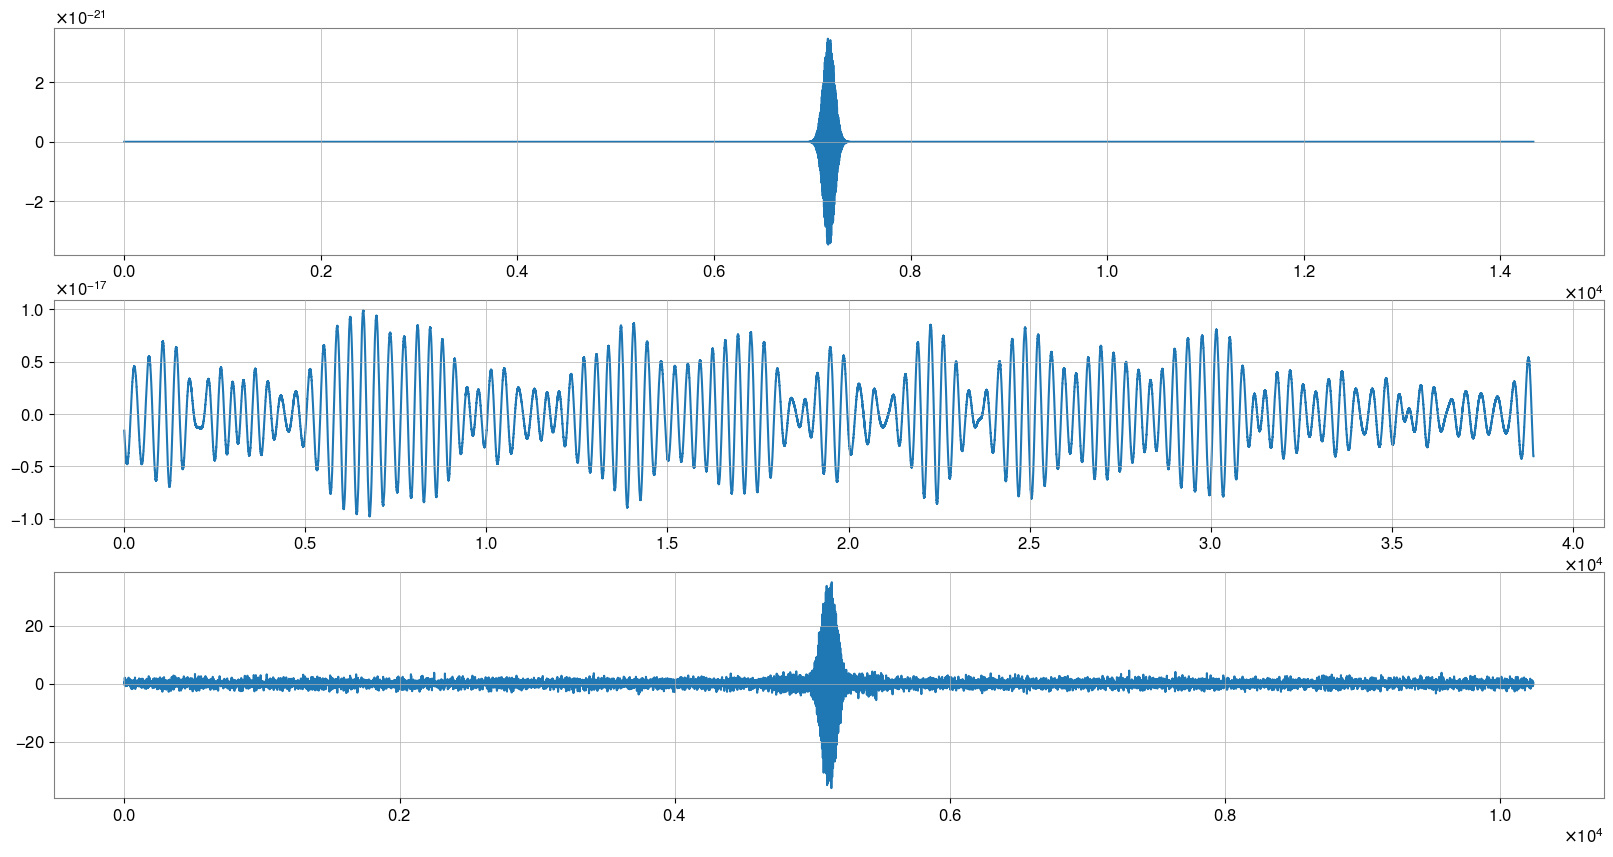

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, figsize=(20,10))
ax[0].plot(datamodule.waveforms[0][0])
ax[1].plot(batch[0][0])
ax[2].plot(strain[0][0])
